*by:* ***Igor Mercês***

---


# Análise de dados do Airbnb - Nova York
A startup Airbnb é considerada a **maior empresa hoteleira** da atualidade sem possuir um **único hotel**.

Presente em mais de 220 países, o Airbnb pratica o modelo de negócio do tipo plataforma multilateral, conectando turístas (consumidores) a donos de locais para hospedágem (fornecedores) em sua plataforma digital de maneira **prática** e **inovadora**.

Até 2025, a Startup fundada em 2007, já havia **hospedado mais de 2 bilhões** de pessoas ao redor de todo o mundo, desafiando as redes hoteleiras tradicionais. *(fonte: https://news.airbnb.com/br/about-us/)*

Com o objetivo de fornecer dados para análises dos impacto do Airbnb na economia imobiliária local, o portal open source [inside Airbnb](http://insideairbnb.com/get-the-data.html) extrai dados da própria plataforma do Airbnb para algumas das principais cidades do mundo e os disponibiliza em seu site para consulta pública. Desta forma, é possível obter uma grade quantidade de dados para desenvolver projetos e soluções de *Data Science*.


<center><img alt="Analisando Airbnb" width="10%" src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Flogosmarcas.net%2Fwp-content%2Fuploads%2F2020%2F07%2FAirbnb-Logo-2014-Presente.jpg&f=1&nofb=1"></center>

**Neste *notebook*, são analisados os dados referentes à cidade de Nova York, em busca de *insights* que podem ser extraídos a partir de dados brutos.**

## A cidade de Nova York

<center><img alt="Analisando Airbnb" width="75%" src="https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fwww.escolhaviajar.com%2Fwp-content%2Fuploads%2F2018%2F03%2Ffotos-de-nova-york-64.jpg&f=1&nofb=1&ipt=ac5d7d16b37e98874479c431e58cfa2ff340083682f36a5ffd97f46a4171fb78"></center>

Com uma economia de **1,8 trilhões de dólares** [segudo o Federal Reserve](https://fred.stlouisfed.org/series/NYRGSP), o estado de Nova York se fosse um país, seria a **14ª maior economia do mundo** quando comparamos com [dados do Banco Mundial](https://data.worldbank.org/indicator/NY.GDP.MKTP.CD?most_recent_value_desc=true). Desta forma, a sua capital, a cidade de Nova York, é considerada um dos **principais destinos econômicos e turísticos do mundo**.

Nova York, a cidade que nunca dorme, é uma metrópole exuberante e cosmopolita que cativa visitantes com sua diversidade artística e sua paisagem urbana impressionante. Os icônicos e imponentes arranha-céus, como o Empire State Building, decoram o horizonte, enquanto pontos turísticos como a Estátua da Liberdade e o Central Park oferecem experiências inesquecíveis. Os teatros da Broadway proporcionam espetáculos de classe mundial, refletindo o protagonismo artístico e cultural da cidade. Museus renomados, como o Metropolitan Museum of Art, entregam uma experiêmcia cultural muito rica para seus visitantes, enquanto bairros como Chinatown e Little Italy proporcionam uma viagem gastronômica única. NYC, como também é conhecida a cidade, é um incrível local de compras, eventos e shows, como a Quinta avenida e suas boutiques de luxo, o SoHO e suas galerias de arte e a famosa Times Square com seus letreiros luminosos e multidões de visitantes dia e noite.

Por todos esses aspectos, a cidade de Nova York possui uma enorme demanda de infraestrutura no setor turístico. Com mais de **56 milhões de visitantes no ano de 2022**, [segundo o governo de Nova York](https://www.state.gov/reporting-tours-foreign-press-centers/new-york-citys-tourism-economy), NYC oferece uma variedade de opções de hospedagens, desde hoteis de luxo a acomodações mais acessíveis. Neste cenário está inserida a plataforma do Airbnb ampliando as opções para aqueles que visitam a cidade.

## Obtenção de dados
Todos os dados deste projeto foram obtidos a partir do site [Inside Airbnb](http://insideairbnb.com/get-the-data.html).

Para esta análise exploratória será utilizado apenas o arquivo

*   `listings.csv` - *Summary information and metrics for listings in New York City (good for visualisations).*

Observação: O portal Inside Airbnb mantém o seu *dataset* em constante atualização e, em determinado momento, o conjunto de dados utilizado neste notebook pode ter sofrido atualização que possa provocar diferenças de resultados para esta versão do projeto. Porém, isto não inviabiliza a reutilização deste notebook, sendo necessária apenas uma nova execução do *dataset* de entrada.




In [1]:
# Importação de pacotes necessários.
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
# Atribuir o arquivo listing.csv a um Dataframe.
df = pd.read_csv("https://data.insideairbnb.com/united-states/ny/new-york-city/2025-11-01/visualisations/listings.csv")

## Análise dos dados
Nesta etapa inicial, temos o objetivo de conhecer os dados e observar como eles estão estruturados. Além disso, é possível criar uma consicência situacional básica para a relação entre as variáveis que serão analisadas.

**Discionário das variáveis**

* `id` - Número gerado para identificar o imóvel
* `name` - Nome da propriedade anunciada
* `host_id` - Número de identificação do proprietário (anfitrião) da propriedade
* `host_name` - Nome do anfitrião
* `neighbourhood_group` - Nome do grupo ao qual o bairro pertence
* `neighbourhood` - Nome do bairro onde se encontra a propriedade
* `latitude` - Coordenada da latitude da propriedade
* `longitude` - Coordenada da longitude da propriedade
* `room_type` - Informa o tipo de quarto que é oferecido
* `price` - Preço para aluguel do imóvel
* `minimum_nights` - Quantidade mínima de noites para reserva
* `number_of_reviews` - Número de reviews que a propriedade possui
* `last_review` - Data do último review
* `reviews_per_month` - Quantidade de reviews por mês
* `calculated_host_listings_count` - Quantidade de imóveis do mesmo anfitrião
* `availability_365` - Número de dias de disponibilidade do imóvel dentro de 365 dias
* `number_of_reviews_ltm` - Quantiade de reviews no último mês
* `license` - Não há informação sobre esta coluna

Antes de iniciar qualquer análise, observamos as **5 primeiras entradas** do *dataset*.

In [3]:
df.head()  # Mostrar as 5 primeiras entradas.

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,1274691077561855573,Beautiful room for rent hosted by Svitlana,658783772,Svitlana,Staten Island,Eltingville,40.535470,-74.151350,Private room,87.0,2,17,2025-10-15,1.62,1,73,17,OSE-STRREG-0002773
1,1274722590671904755,Exquisite & Charming Studio in Prime Locations,458668555,Patricia,Brooklyn,East Flatbush,40.651855,-73.945082,Private room,80.0,30,2,2025-06-30,0.21,6,93,2,NaN
2,1274773188072371454,"Private 2 Bedroom Unit, Full Kitchen, Washer/D...",22369387,Waleed,Staten Island,Silver Lake,40.620370,-74.101954,Entire home/apt,99.0,30,0,NaN,NaN,3,201,0,NaN
3,1274820999428562667,"Beautiful, Serene West Village Treehouse",505544503,Michael,Manhattan,West Village,40.735566,-74.004233,Entire home/apt,312.0,30,0,NaN,NaN,1,317,0,NaN
4,1274826163511555978,Renovated 1BR w/ Spa Shower,493151605,Kareem,Queens,Jamaica,40.704184,-73.783945,Entire home/apt,111.0,30,1,2025-01-03,0.10,4,333,1,NaN


### **Quantidade de atributos (variáveis) e entradas existentes no conjunto de dados e tipos das variáveis**
Nesta etapa, identificamos a quantidade de entradas e de variáveis do *dataset* assim como os tipos destas variáveis.

In [4]:
# Identificar o volume de dados do dataset.
print(f"Entrada:\t{df.shape[0]}")
print(f"Variáveis:\t{df.shape[1]}\n")

df.dtypes  # Verificar os tipos das variáveis do dataset.

Entrada:	36353
Variáveis:	18



,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


### Porcentagem de valores ausentes no dataset
A qualidade de um dataset está diretamente relacionada à quantidade de valores ausentes. No início da análise exploratória é importante identificar se existem valores nulos ou ausentes e se estes são significativos quando comparados com o total de entradas existentes.

In [5]:
df.isnull().sum()  # Quantidade de valores auxentes por variável.

,0
id,0
name,2
host_id,0
host_name,1457
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,14938


In [6]:
# Exibir a porcentagem em ordem decrescente das variáveis pelos seus valores ausentes.
(df.isnull().sum() / df.shape[0]).sort_values(ascending=False)

,0
license,0.854923
price,0.410915
reviews_per_month,0.312106
last_review,0.312106
host_name,0.040079
name,0.000055
id,0.000000
neighbourhood,0.000000
neighbourhood_group,0.000000
host_id,0.000000



É possível identificar que:
*   A coluna `license` possui 85% dos seus valores ausentes.
*   A coluna `price` possui 41% de valores ausentes.
*   As colunas `reviews_per_month` e `last_review` possuem 31% dos seus valores ausentes.
*   A coluna `host_name` possui 0,04% de valores ausentes.


Para este estudo, optou-se por excluir as amostras com valores ausentes para a coluna `price`.

In [7]:
df_clean = df.copy()  # Copiar o dataframe.

df_clean.dropna(subset="price", inplace=True)

### Distribuição das variáveis
Para visualizar a distribuição das variáveis, um histograma é muito útil.

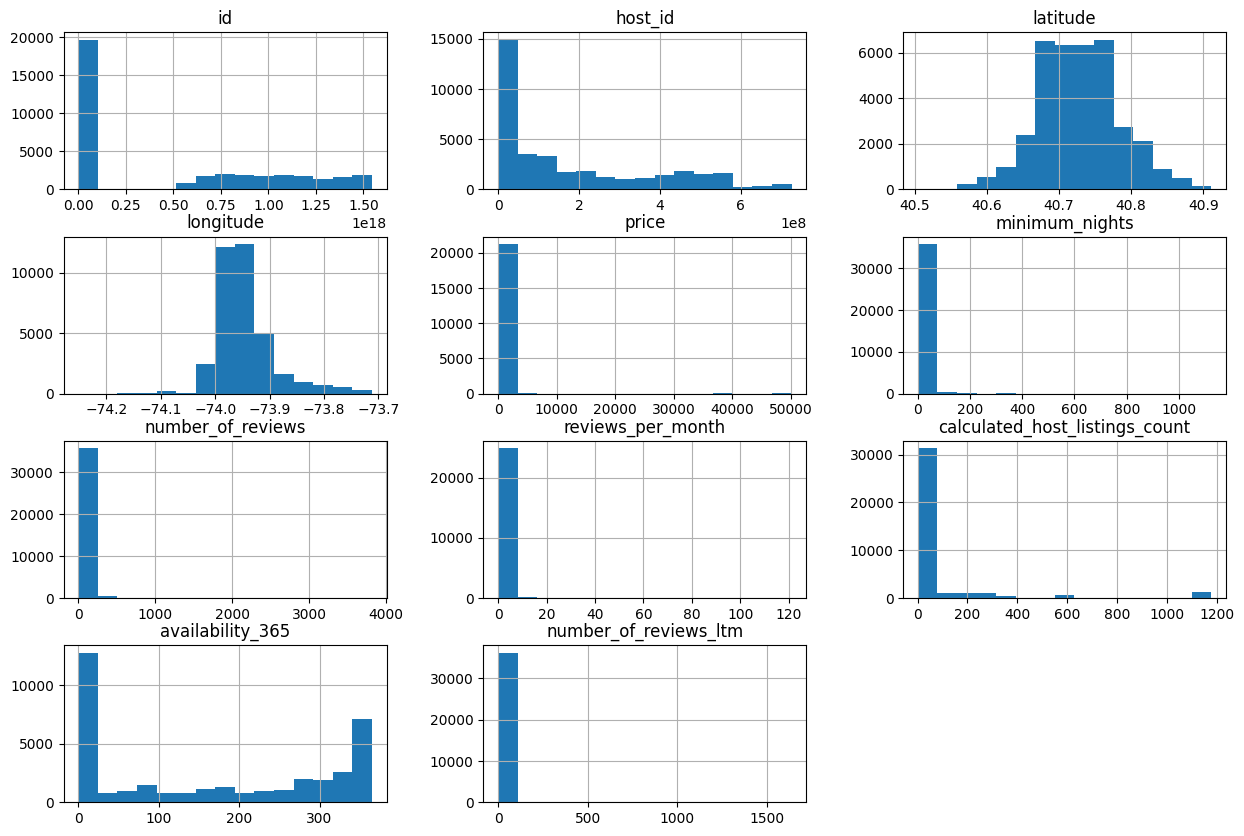

In [8]:
df.hist(bins=15, figsize=(15, 10));  # ; no final para deixar o gráfico mais limpo

### Verificação de *Outliers*
Pela distribuição dos histogramas, é possível observar a presença de *outliers*, como por exemplo nas variáveis `price` e `minimum_nights`.

*Outliers* não seguem uma distruição e distorcem toda a representação gráfica. Há duas maneiras rápidas que auxiliam na detecção de *outliers* e estas são:

* Resumo estatístico por meio do método `describe()`
* Plotar `boxplots` para a variável.


#### Resumo estatístico

In [8]:
df_clean[["price",
          "minimum_nights",
          "number_of_reviews",
          "reviews_per_month",
          "calculated_host_listings_count",
          "availability_365",
          "number_of_reviews_ltm",
          ]].describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
count,21415.000000,21415.000000,21415.000000,15000.000000,21415.000000,21415.000000,21415.000000
mean,519.622881,26.907775,36.775531,1.150749,98.280644,252.505393,6.334345
std,3658.430988,24.260443,85.949776,2.308954,267.056401,108.221711,24.228933
min,9.000000,1.000000,0.000000,0.010000,1.000000,0.000000,0.000000
25%,90.000000,30.000000,0.000000,0.170000,1.000000,169.000000,0.000000
50%,154.000000,30.000000,5.000000,0.445000,3.000000,283.000000,0.000000
75%,269.000000,30.000000,38.000000,1.430000,25.000000,351.000000,3.000000
max,50138.000000,729.000000,3817.000000,121.170000,1178.000000,365.000000,1639.000000


Observando o resumo estatístico acima, podemos destacar que:


*   A variável `price` possui 75% dos seus valores abaixo de 269, porém possui valor máximo de 50138.
*   A variável `minimum_nights` (mínimo de noites) possui valor máximo de 1124, acima de 365 noites.



####Boxplot para price

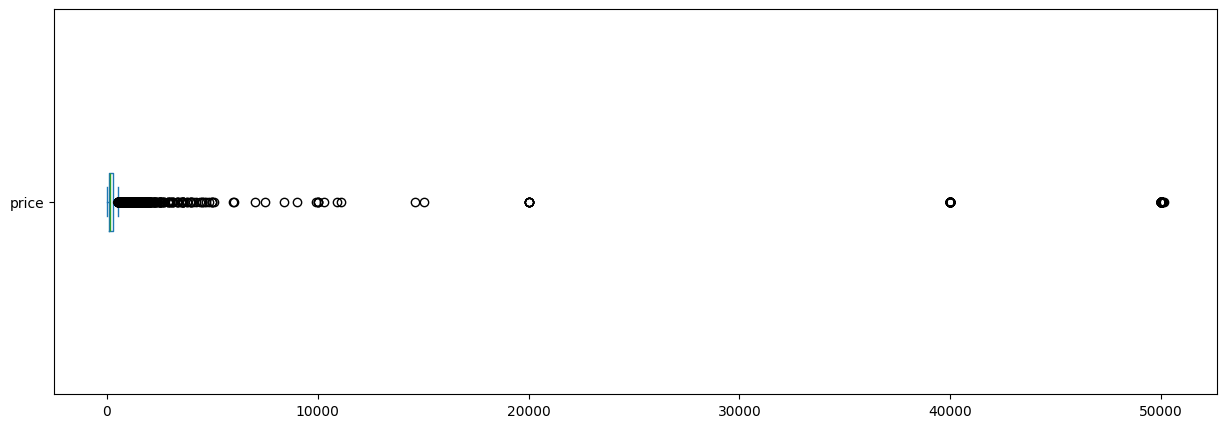


Valores acima de 500:
-- 1569 entradas
-- 7.3266% em relação ao total


In [9]:
# Boxplot para a variável price.
df_clean["price"].plot(kind="box", vert=False, figsize=(15, 5))
plt.show()

# Ver quantidade de valores acima de 500.
print("\nValores acima de 500:")
print(f"-- {df_clean[df_clean.price > 500].shape[0]} entradas")
print(f"-- {(df_clean[df_clean.price > 500].shape[0] / df_clean.shape[0]) * 100:.4f}% em relação ao total")

####Boxplot para minimum_nights

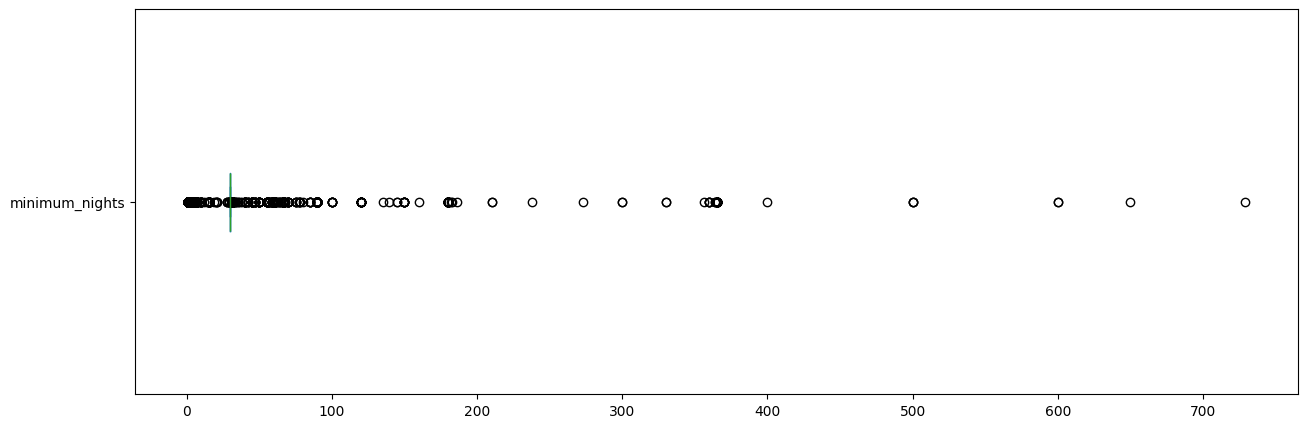


Valores acima de 30:
-- 1711 entradas
-- 7.9897% em relação ao total


In [10]:
# Boxplot para variável a minimum_nights.
df_clean["minimum_nights"].plot(kind="box", vert=False, figsize=(15, 5))
plt.show()

# Ver quantidade de valores acima de 30.
print("\nValores acima de 30:")
print(f"-- {df_clean[df_clean.minimum_nights > 30].shape[0]} entradas")
print(f"-- {(df_clean[df_clean.minimum_nights > 30].shape[0] / df_clean.shape[0]) * 100:.4f}% em relação ao total")

#### Histograma sem *outliers*
Após a idendificação dos *outliers*, podemos limpar o *dataframe* retirando estes valores das variáveis `price` e `minimum_nights` e, em seguida, plotar um novo histograma.

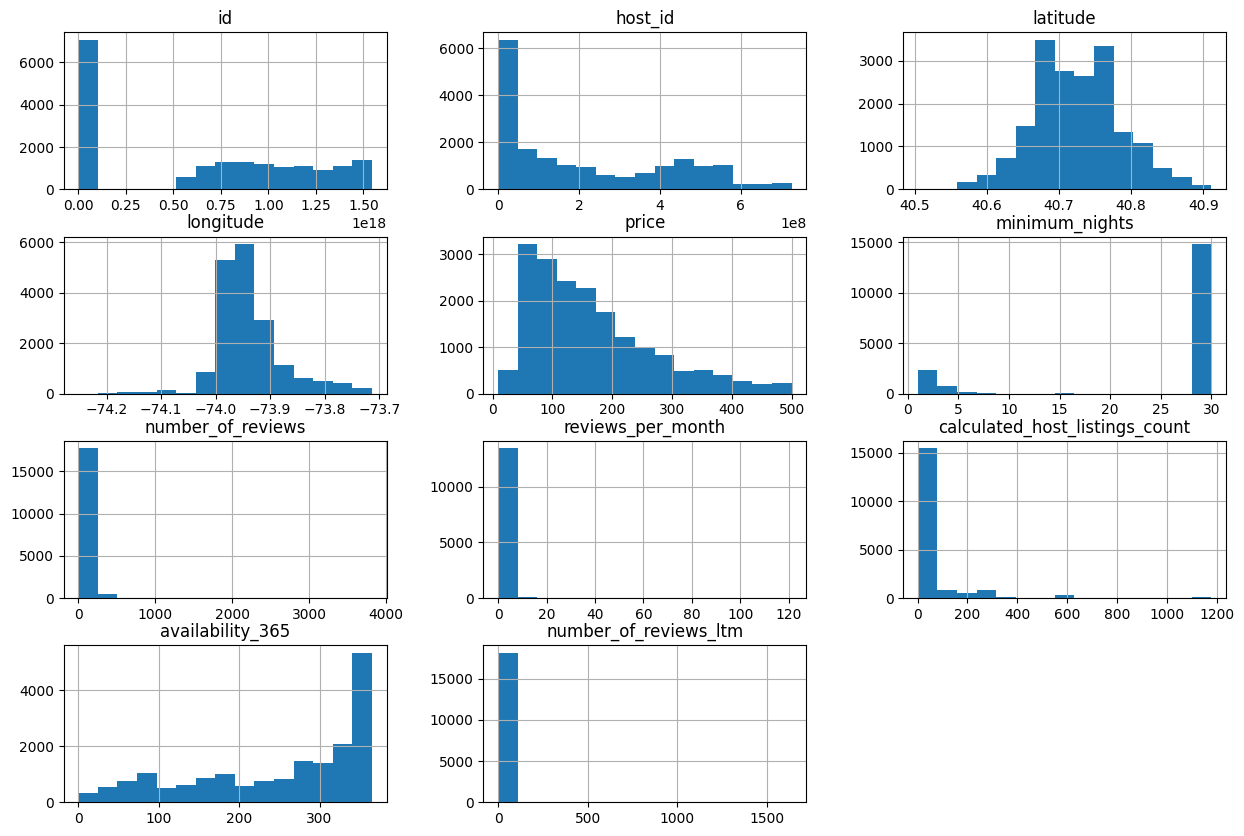

In [11]:
# Remover os outliers do novo dataframe.
df_clean.drop(df_clean[df_clean.price > 500].index, axis=0, inplace=True)
df_clean.drop(df_clean[df_clean.minimum_nights > 30].index, axis=0, inplace=True)

# Remover variável license, pois é vazia.
df_clean.drop("license", axis=1, inplace=True)

# Plotar histograma para as variáveis numéricas.
df_clean.hist(bins=15, figsize=(15, 10));

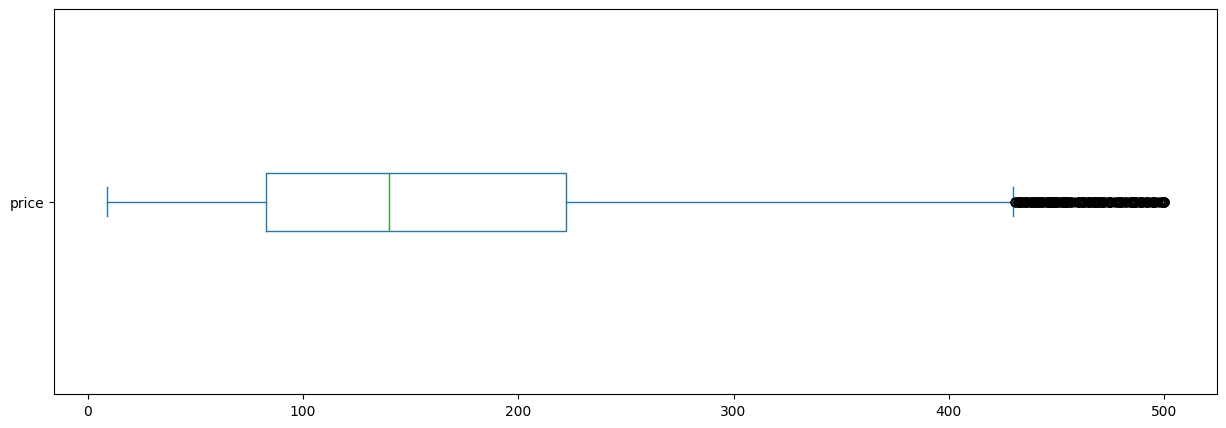

In [12]:
# Boxplot para variável a minimum_nights.
df_clean.price.plot(kind="box", vert=False, figsize=(15, 5))

plt.show()

### Correlação entre as variáveis
A correlação descreve a associação entre duas variáveis. Para sabermos a relação linear entre as variáveis do *dataset*, estabelecemos o coeficiente de correlação por meio de duas etapas:


*   Criar uma matriz de correlação
*   Gerar um heatmap a partir dessa matriz, usando a biblioteca `seaborn`



In [13]:
# Criar matriz do coeficiente de correlação.
df_correlation = df_clean[["price",
                           "minimum_nights",
                           "number_of_reviews",
                           "reviews_per_month",
                           "calculated_host_listings_count",
                           "availability_365",
                           "number_of_reviews_ltm"
                           ]].corr()

df_correlation

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
price,1.000000,-0.234960,0.037452,0.136000,0.031697,0.049417,0.100240
minimum_nights,-0.234960,1.000000,-0.352753,-0.470496,0.136303,0.157921,-0.488232
number_of_reviews,0.037452,-0.352753,1.000000,0.736894,-0.135610,-0.083262,0.671829
reviews_per_month,0.136000,-0.470496,0.736894,1.000000,-0.113314,-0.049666,0.904067
calculated_host_listings_count,0.031697,0.136303,-0.135610,-0.113314,1.000000,0.047305,-0.074059
availability_365,0.049417,0.157921,-0.083262,-0.049666,0.047305,1.000000,-0.079482
number_of_reviews_ltm,0.100240,-0.488232,0.671829,0.904067,-0.074059,-0.079482,1.000000


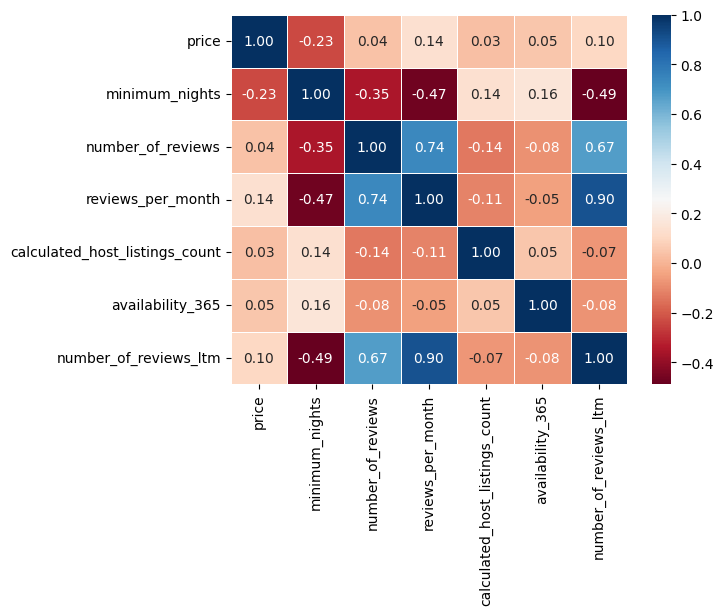

In [14]:
# Plotar heatmap utilizando seaborn.
sns.heatmap(df_correlation,
            cmap="RdBu",
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            );

### Tipo de imóvel mais frequente no Airbnb
A variável `room_type` indica o tipo de locação que está anunciada no Airbnb. Existem opções de apartamentos/casas inteiras, apenas o aluguel de um quarto ou até mesmo dividir o quarto com outras pessoas.

Vamos contar a quantidade de ocorrências e o tipo de cada aluguel, usando o método `value_counts()`.

In [15]:
df_clean.room_type.value_counts()  # Mostrar quantidade e tipo de aluguéis disponíveis.

,count
room_type,
Entire home/apt,9940
Private room,8096
Shared room,158
Hotel room,32


In [16]:
(df_clean.room_type.value_counts() / df_clean.shape[0]) * 100  # Mostrar a frequência em porcentagem.

,count
room_type,
Entire home/apt,54.537474
Private room,44.420059
Shared room,0.866893
Hotel room,0.175573


### Bairros mais valorizados de Nova York

<center><img alt="Analisando Airbnb" width="60%" src="https://s-media-cache-ak0.pinimg.com/originals/eb/8f/82/eb8f82555f88f8364929e5e829702caf.jpg"></center>


A cidade de Nova York é composta por 5 grandes bairros (boroughs): **Manhattan**, **Brooklyn**, **Queens**, **Bronx** e **Staten Island**

Desta forma podemos classificar os bairros segundo a média do preço do aluguel.

In [17]:
# Agrupar neighbourhood_group e calcular a média de preço.
df_mean_price_by_neighbourhood_group = (df_clean
                                        .groupby(by="neighbourhood_group")["price"]
                                        .mean()
                                        .sort_values(ascending=False)
                                        .to_frame()
                                        )

# Contar a quantidade de entradas para cada neighbourhood_group.
df_neighbourhood_group_count = (df_clean["neighbourhood_group"]
                                .value_counts()
                                .to_frame()
                                )

# Juntar os dois dataframes anteriores.
df_neighbourhood_group_aggregated = (df_mean_price_by_neighbourhood_group
                                     .merge(right=df_neighbourhood_group_count,
                                            how="left",
                                            left_index=True,
                                            right_index=True,
                                            )
                                     )

# Nomeiar as colunas.
df_neighbourhood_group_aggregated.columns = ["price", "quantity"]

df_neighbourhood_group_aggregated

,price,quantity
neighbourhood_group,,
Manhattan,205.668148,7199
Brooklyn,150.990428,6686
Queens,123.798157,3255
Bronx,113.934094,789
Staten Island,109.973064,297


A ilha de Manhattan é a parte mais famosa e valorizada da cidade de Nova York. Localizada no centro da cidade, concentra a maior quantidade de vizinhanças nobres e pontos turísticos como a Broadway, Times Square e o Central Park.

Por estes motivos, Manhattan aparece na tabela acima como o bairro mais valorizado da cidade e também oferencendo a maior quantidade de imóveis disponíveis para aluguel.

### Vizinhanças mais caras em Nova York
Utilizando o método `groupby`, vamos agrupar os valores para `neighbourhood` (vizinhanças) e `neighbourhood_group` e comparamos eles a partir do preço de locação.

In [18]:
# Agrupar neighbourhood e calcula a média de preço.
df_mean_price_by_neighbourhood = (df_clean
                                  .groupby(by=["neighbourhood", "neighbourhood_group"], as_index=False)["price"]
                                  .mean()
                                  .sort_values(by="price", ascending=False)[:25]
                                  .set_index("neighbourhood")
                                  )

# Contar a quantidade de entradas para cada neighbourhood.
df_neighbourhood_count = (df_clean["neighbourhood"]
                          .value_counts()
                          .to_frame()
                          )

# Juntar os dois dataframes anteriores.
df_neighbourhood_aggregated = (df_mean_price_by_neighbourhood
                               .merge(right=df_neighbourhood_count,
                                      how="left",
                                      left_index=True,
                                      right_index=True,
                                      )
                               )

# Nomeiar as colunas.
df_neighbourhood_aggregated.columns = ["neighbourhood_group", "price", "quantity"]
df_neighbourhood_aggregated

,neighbourhood_group,price,quantity
neighbourhood,,,
Tribeca,Manhattan,322.294118,34
Theater District,Manhattan,318.236842,114
Financial District,Manhattan,307.151515,198
DUMBO,Brooklyn,305.083333,12
SoHo,Manhattan,294.322581,62
Civic Center,Manhattan,293.800000,5
Neponsit,Queens,290.000000,2
Holliswood,Queens,289.500000,2
Flatiron District,Manhattan,278.833333,36


In [19]:
# Contagem de valores na coluna neighbourhood_group.
df_neighbourhood_aggregated["neighbourhood_group"].value_counts()

,count
neighbourhood_group,
Manhattan,13
Brooklyn,7
Queens,3
Bronx,1
Staten Island,1


Das 25 vizinhanças com a maior média de preço, **13 estão no bairro de Manhattan**.

Mesmo para quem não é familiarizado com as vizinhanças de Nova York, após uma pequisa rápida, podemos nos informar que locais como **Tribeca**, **Soho** e **Financial District** são umas das vizinhanças mais valorizados da cidade. Porém, na lista acima observamos que um locais modestos como Neponsit e Holliswood ocupam posições superiores às vizinhanças conhecidamente mais valorizados, como a Flatiron District.

Pela tabela anterior, observamos que existe apenas dois anúncio para Neponsit e para Holliswood. Vamos verificar este fato na fonte de dados.

In [20]:
# Ver quantidade de imóveis.
quantity = (df_clean
              .query("neighbourhood == ['Neponsit', 'Holliswood']")
              .shape[0]
              )
print(f"Entradas:\t{quantity}")

# Ver as entradas com imóveis.
df_clean.query("neighbourhood == ['Neponsit', 'Holliswood']")


Entradas:	4


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm
4637,9127163,Quiet Retreat yet convenient to all NYC amenities,47546771,June,Queens,Holliswood,40.72199,-73.76795,Private room,94.0,30,4,2019-06-02,0.04,1,89,0
10411,24910361,"""The Little House by the Sea""",188328775,Donna,Queens,Neponsit,40.56948,-73.85941,Entire home/apt,295.0,30,29,2023-06-19,0.32,1,178,0
18462,51619751,A place to stay recovering from major surgery.,85202728,Lourdes,Queens,Holliswood,40.72358,-73.76821,Entire home/apt,485.0,30,3,2023-07-01,0.06,1,364,0
29558,1105123568565389419,Country Beach Surf Loft,62608664,David,Queens,Neponsit,40.56935,-73.86156,Entire home/apt,285.0,30,0,NaN,NaN,1,269,0


Podemos observar que as vizinhanças de **Neponsit** e **Holliswood** possuem ambos 2 imóveis disponíveis. A pouca quantidade de imóvel nesses locais causa uma **falsa realidade** de que o preço do aluguel é **alto**.


### Mapa dos imóveis
É possível plotar cada imóvel no mapa utilizando as suas informações de **latitude** e **longitude**. Para isso, podemos utilizar um gráfico de **dispersão** com as coordenadas `x=longitude` e `y=latitude` e uma escala de cores para os preços do aluguel.

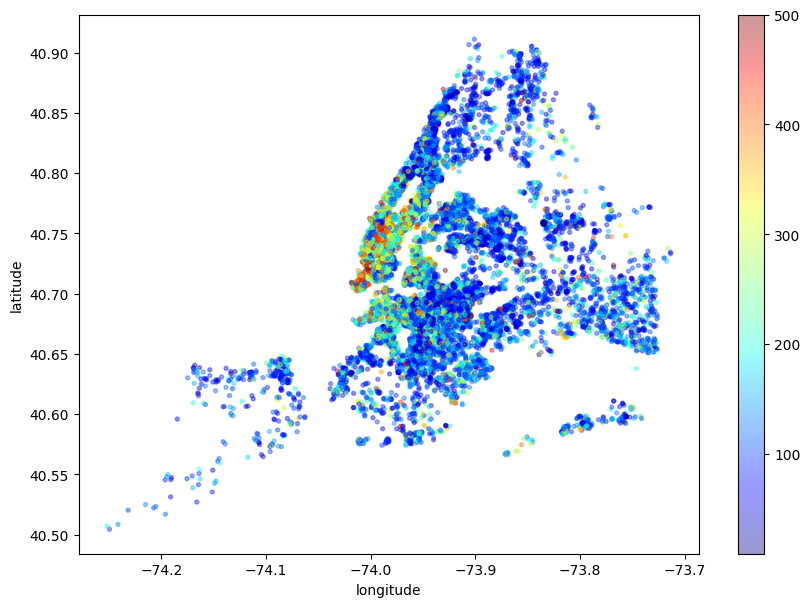

In [21]:
# Plotar os imóveis pela latitude e longitude.
df_clean.plot(kind="scatter",
              x="longitude",
              y="latitude",
              alpha=0.4,
              c=df_clean["price"],
              s=8,
              cmap=plt.get_cmap("jet"),
              figsize=(10,7),
              );

## Conclusão

Neste projeto, foi feita uma análise superficial da base de dados do Airbnb, porém foi possível perceber a existência de *outliers* em algumas variáveis que distorcem as informações estatísticas retirada do conjunto inteiro de dados. A presença de valores ausentes também foi um ponto importante a se considerar.

A presença de bairros com poucos imóveis foi fundamental para afirmar a hipótese dos *outliers* e contribuiram para que houvesse um tratamento da base de dados utilizada.

O *dataset* utilizado é uma versão resumida, ideal apenas para uma abordagem inicial. Recomenda-se que seja usado, em uma próxima análise exploratória, o conjunto de dados completo, com mais atributos disponíveis para uma análise mais detalhada, permitindo atribuir conlcusões mais profundas aos dados analisados.